In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_s_curve

from Autoencoders import Autoencoder
from helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler
from data import make_half_sphere

random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


/home/maxheise/anaconda3/envs/ML/lib/python3.13/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
    
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    
    def forward(self, z):
        return self.fc(z)

In [3]:
data, labels = make_half_sphere(n_samples=2000, noise=0.05, random_state=random_state)
data = torch.tensor(data, dtype=torch.float32).to(device)
val_data, val_labels = make_half_sphere(n_samples=1000, noise=0.05, random_state=random_state)
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)

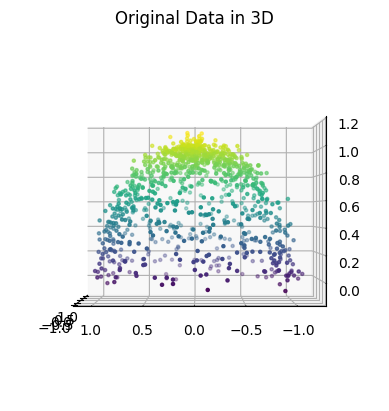

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0].cpu(), data[:, 1].cpu(), data[:, 2].cpu(), c=labels, s=5)
ax.set_title("Original Data in 3D")
ax.view_init(0, 180, 0)
plt.show()

In [5]:
# define model parameters
latent_dim = 2
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 64

train_dataloader = DataLoader(data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

model_path = "models/conformal_autoencoder_half_sphere.pth"
optimizer_path = "models/conformal_autoencoder_half_sphere_optimizer.pth"

In [6]:
from metrics import conformality_angle_loss, conformality_loss

In [7]:
class ConformalAutoencoder(Autoencoder):
    def __init__(self, encoder, decoder, lambda_conf=0.1):
        super(ConformalAutoencoder, self).__init__(encoder, decoder)
        self.name = "ConformalAutoencoder"
        self.lambda_conf = lambda_conf

        self.conformality_loss = conformality_loss

        self.metrics_list = {"reconstruction_loss": [], "conformal_loss": [], "conformal_angle_loss": []}
        self.val_metrics_list = {"reconstruction_loss": [], "conformal_loss": [], "conformal_angle_loss": []}

    def get_metrics(self, x, val=False):
        # Compute all relevant metrics
        z = self.encode(x)
        x_reconstructed = self.decode(z)
        reconstruction_loss = nn.MSELoss()(x_reconstructed, x)
        conformal_loss = self.conformality_loss(self.decoder, z)
        conformal_angle_loss = conformality_angle_loss(self.decoder, z)
        return [reconstruction_loss, conformal_loss, conformal_angle_loss]
    
    def get_loss(self, metrics):
        # Combine metrics to compute loss
        reconstruction_loss, conformal_loss, conformal_angle_loss = metrics
        return reconstruction_loss + self.lambda_conf * conformal_angle_loss
    
    def get_batch_loss(self, loss_list):
        # Compute the average loss for the batch
        batch_loss = torch.mean(torch.tensor(loss_list))
        return batch_loss
    
    def get_batch_metrics(self, metrics):
        # Compute the average metrics for the batch
        batch_reconstruction_loss = torch.mean(torch.tensor(metrics)[:, 0]).item()
        batch_conformal_loss = torch.mean(torch.tensor(metrics)[:, 1]).item()
        batch_conformal_angle_loss = torch.mean(torch.tensor(metrics)[:, 2]).item()
        return [batch_reconstruction_loss, batch_conformal_loss, batch_conformal_angle_loss]
    
    def log_loss_and_metrics(self, batch_loss, batch_metrics, epoch, epochs, val=False):
        # Log the loss and metrics for monitoring
        reconstruction_loss, conformal_loss, batch_conformal_angle_loss = batch_metrics
        if val:
            print(f'Epoch [{epoch + 1}/{epochs}], Validation Loss: {batch_loss.item():.8f}, Reconstruction Loss: {reconstruction_loss:.8f}, Conformal Loss: {conformal_loss:.8f}')
        else:
            print(f'Epoch [{epoch + 1}/{epochs}], Loss: {batch_loss.item():.8f}, Reconstruction Loss: {reconstruction_loss:.8f}, Conformal Loss: {conformal_loss:.8f}')

    def track_loss_and_metrics(self, batch_loss, batch_metrics, val=False):
        # Track and save the loss and metrics for monitoring
        reconstruction_loss, conformal_loss, conformal_angle_loss = batch_metrics
        if val:
            self.val_loss_list.append(batch_loss.item())
            self.val_metrics_list["reconstruction_loss"].append(reconstruction_loss)
            self.val_metrics_list["conformal_loss"].append(conformal_loss)
            self.val_metrics_list["conformal_angle_loss"].append(conformal_angle_loss)
        else:
            self.loss_list.append(batch_loss.item())
            self.metrics_list["reconstruction_loss"].append(reconstruction_loss)
            self.metrics_list["conformal_loss"].append(conformal_loss)
            self.metrics_list["conformal_angle_loss"].append(conformal_angle_loss)


In [8]:
encoder = Encoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim, output_dim=output_dim).to(device)
conformal_autoencoder = ConformalAutoencoder(encoder, decoder, lambda_conf=10.0).to(device)
optmizer, scheduler = conformal_autoencoder.train_model(train_dataloader, val_dataloader, batch_size=batch_size, epochs=1000, learning_rate=0.001, log_every=100, val_every=100, scheduler_kwargs={"step_size": 100, "gamma": 0.5})

Epoch [100/1000], Loss: 0.00270281, Reconstruction Loss: 0.00152959, Conformal Loss: 0.00056311
Epoch [100/1000], Validation Loss: 0.00263349, Reconstruction Loss: 0.00156432, Conformal Loss: 0.00052819
Epoch [200/1000], Loss: 0.00170149, Reconstruction Loss: 0.00124345, Conformal Loss: 0.00013715
Epoch [200/1000], Validation Loss: 0.00179562, Reconstruction Loss: 0.00127364, Conformal Loss: 0.00016082
Epoch [300/1000], Loss: 0.00139656, Reconstruction Loss: 0.00105091, Conformal Loss: 0.00007137
Epoch [300/1000], Validation Loss: 0.00150579, Reconstruction Loss: 0.00111628, Conformal Loss: 0.00008740
Epoch [400/1000], Loss: 0.00125052, Reconstruction Loss: 0.00099268, Conformal Loss: 0.00005157
Epoch [400/1000], Validation Loss: 0.00144919, Reconstruction Loss: 0.00109126, Conformal Loss: 0.00007413
Epoch [500/1000], Loss: 0.00117797, Reconstruction Loss: 0.00094699, Conformal Loss: 0.00003939
Epoch [500/1000], Validation Loss: 0.00143384, Reconstruction Loss: 0.00108281, Conformal Lo

In [7]:
conformal_autoencoder.save_checkpoint(model_path)
save_optimizer_and_scheduler(optimizer_path, optmizer, scheduler)

Checkpoint saved to models/conformal_autoencoder_half_sphere.pth at epoch 1001
Optimizer and scheduler saved to models/conformal_autoencoder_half_sphere_optimizer.pth


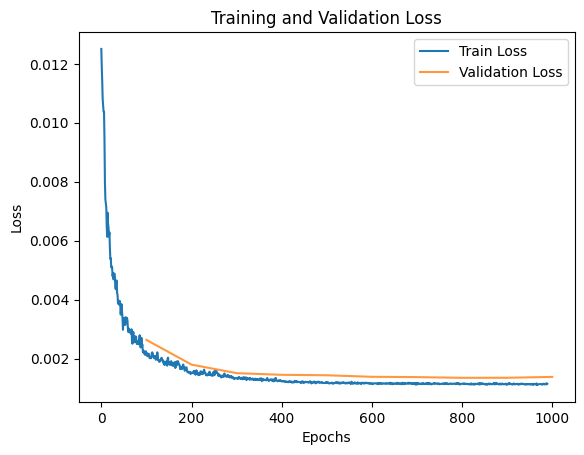

In [9]:
plt.plot(conformal_autoencoder.loss_list[10:], label='Train Loss')
plt.plot(np.linspace(100, 1000, 10), conformal_autoencoder.val_loss_list, alpha=0.8, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

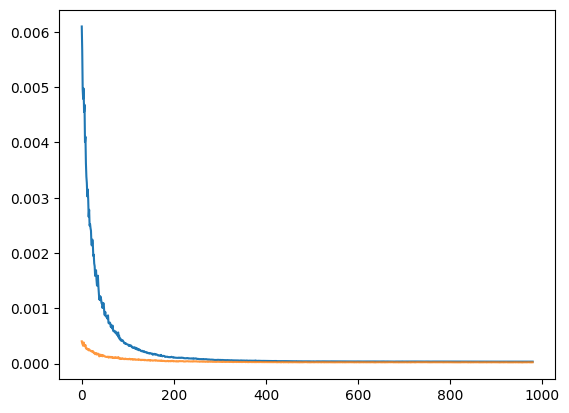

In [10]:
plt.plot(conformal_autoencoder.metrics_list["conformal_loss"][20:], label='Train Conformal Loss')
plt.plot(conformal_autoencoder.metrics_list["conformal_angle_loss"][20:], label='Validation Conformal Angle Loss', alpha=0.8)

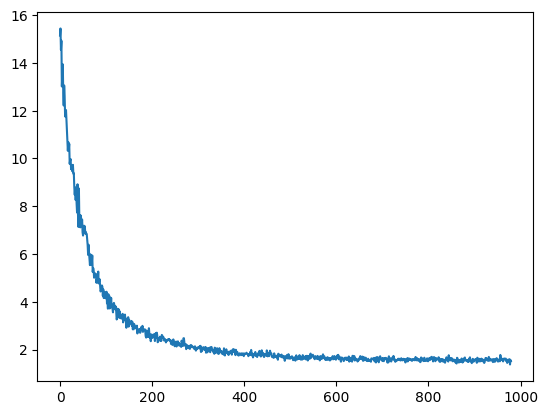

In [11]:
plt.plot(np.array(conformal_autoencoder.metrics_list["conformal_loss"][20:])/np.array(conformal_autoencoder.metrics_list["conformal_angle_loss"][20:]), label='Train Conformal Loss')

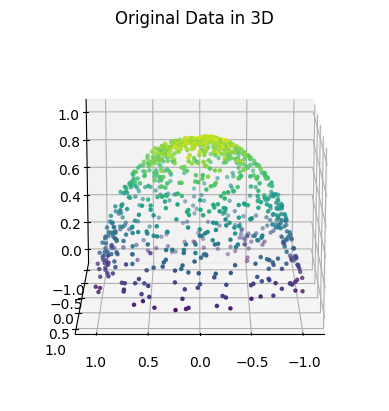

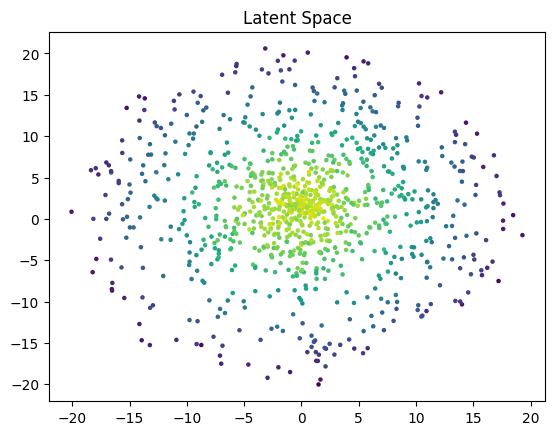

In [12]:
#Encode the data
encoded_data = conformal_autoencoder.encode(data)
# Decode the data
decoded_data = conformal_autoencoder.decode(encoded_data).cpu().detach()
encoded_data = encoded_data.cpu().detach()

# Visualize the reconstruction
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(decoded_data[:, 0], decoded_data[:, 1], decoded_data[:, 2], c=labels, cmap='viridis', s=5)
ax.set_title("Original Data in 3D")
ax.view_init(15, 90, 0)
plt.show()
# Visualize the latent space
plt.scatter(encoded_data[:, 0], encoded_data[:, 1], c=labels, cmap='viridis', s=5)
plt.title("Latent Space")
plt.show()

In [14]:
num = 900
J = torch.zeros((num, 2, 2))
for i in range(num):
    latent = encoder(data[i:i+1])
    jac = torch.autograd.functional.jacobian(decoder, latent)
    jac = jac[0,:,0,:]
    J[i] = jac.T @ jac
print(J.mean(dim=0))
print(J.std(dim=0))

tensor([[3.3372e-04, 1.5667e-07],
        [1.5667e-07, 3.3490e-04]])
tensor([[3.3081e-05, 1.5537e-05],
        [1.5537e-05, 3.6233e-05]])


In [12]:
# Load the model and optimizer from checkpoint
encoder = Encoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim, output_dim=output_dim).to(device)
autoencoder = ConformalAutoencoder(encoder, decoder).load_model_from_checkpoint(model_path).to(device)
optimizer = autoencoder.get_default_optimizer()
scheduler = autoencoder.get_default_scheduler(optimizer)
optimizer, scheduler = load_optimizer_and_scheduler(optimizer_path, optimizer, scheduler)

Model and custom variables loaded from models/conformal_autoencoder_half_sphere.pth
Optimizer and scheduler loaded from models/conformal_autoencoder_half_sphere_optimizer.pth
